# Audio Denoising & Speech Recovery Pipeline

## 1. Introduction & Objectives
In modern communication systems, signals often become corrupted by additive interference during transmission or recording. In this task, we are given a degraded audio recording (`noisy_speech_sample.wav`) where a spoken word is masked by a loud, high-amplitude periodic buzz noise.

### Objectives:
1. **Analyze** the spectral properties of the corrupted audio to detect noise frequencies.
2. **Design** a DSP filtering pipeline (Cascade of Notch Filters + Bandpass Filter) to eliminate the buzz while preserving speech intelligibility.
3. **Filter** the signal with zero phase distortion (`filtfilt`).
4. **Visualize** the time-domain waveforms, FFT magnitude spectra, and spectrograms before and after filtering.
5. **Play** the recovered cleaned audio to clearly hear the hidden secret word.


## 2. Environment Setup & Library Imports


In [3]:
import os
import numpy as np
from scipy.io import wavfile
from scipy import signal
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10


## 3. Load Corrupted Audio Signal


In [4]:
audio_path = 'noisy_speech_sample.wav'
sr, data = wavfile.read(audio_path)

if data.ndim > 1:
    data = data[:, 0]

data_float = data.astype(np.float64)
duration = len(data) / sr

print(f"Sampling Rate : {sr} Hz")
print(f"Total Samples : {len(data)}")
print(f"Duration      : {duration:.3f} seconds")
print(f"Amplitude Min/Max: [{np.min(data)}, {np.max(data)}]")

print("\nPlaying Corrupted Audio (Warning: Loud Buzz):")
display(Audio(data, rate=sr))


Sampling Rate : 48000 Hz
Total Samples : 53625
Duration      : 1.117 seconds
Amplitude Min/Max: [-32767, 32767]

Playing Corrupted Audio (Warning: Loud Buzz):


## 4. Frequency Domain Analysis (FFT) & Noise Detection
We compute the Discrete Fourier Transform (via `np.fft.rfft`) to reveal the frequency spikes. The buzz noise manifests as a periodic comb of sharp interference tones. We use a local median filter to detect peaks exceeding the local spectral baseline.


In [5]:
N = len(data_float)
freqs = np.fft.rfftfreq(N, 1 / sr)
fft_mag = np.abs(np.fft.rfft(data_float))

# Estimate baseline spectrum using a median filter
window_bins = int(500 * N / sr) | 1
baseline = median_filter(fft_mag, size=window_bins)
spectral_ratio = fft_mag / (baseline + 1e-6)

# Detect prominent noise spikes
peak_indices, _ = signal.find_peaks(
    spectral_ratio,
    height=4.0,
    distance=int(5 * N / sr)
)
detected_freqs = freqs[peak_indices]

print(f"Detected {len(detected_freqs)} distinct buzz interference frequencies.")
print("First 10 detected frequencies (Hz):")
for f in detected_freqs[:10]:
    print(f"  - {f:8.2f} Hz")


Detected 440 distinct buzz interference frequencies.
First 10 detected frequencies (Hz):
  -    68.92 Hz
  -   169.17 Hz
  -   293.59 Hz
  -   307.02 Hz
  -   319.55 Hz
  -   332.98 Hz
  -   470.83 Hz
  -   657.90 Hz
  -   708.92 Hz
  -   722.35 Hz


## 5. DSP Filter Design & Zero-Phase Filtering
We apply a two-stage filtering strategy:
1. **Cascade of IIR Notch Filters (`scipy.signal.iirnotch`)**:
   Each notch filter has a high Quality factor ($Q \ge 30$) to surgically suppress the exact buzz tone with minimal bandwidth loss, preserving adjacent speech formants.
2. **Butterworth Bandpass Filter (80 Hz - 4000 Hz)**:
   Restricts the signal to standard human speech frequency range, eliminating low rumble and ultra-high frequency buzz harmonics.
3. **Zero-Phase Filtering (`scipy.signal.filtfilt`)**:
   Processes the signal forward and backward to achieve exactly $0^\circ$ phase shift, preventing temporal distortion or smearing of consonants and vowels.


In [6]:
filtered_audio = data_float.copy()

# 1. Apply Cascade of IIR Notch Filters
notch_count = 0
for f0 in detected_freqs:
    if 20 < f0 < (sr / 2 - 20):
        Q = max(30.0, f0 / 5.0)
        b, a = signal.iirnotch(w0=f0, Q=Q, fs=sr)
        filtered_audio = signal.filtfilt(b, a, filtered_audio)
        notch_count += 1

print(f"Applied {notch_count} IIR Notch Filters.")

# 2. Apply 4th-Order Butterworth Bandpass Filter (80 Hz - 4000 Hz)
lowcut, highcut = 80.0, min(4000.0, sr / 2 - 100.0)
b_bp, a_bp = signal.butter(N=4, Wn=[lowcut, highcut], btype='bandpass', fs=sr)
filtered_audio = signal.filtfilt(b_bp, a_bp, filtered_audio)
print(f"Applied Butterworth Bandpass Filter [{lowcut:.0f} Hz - {highcut:.0f} Hz].")

# 3. Normalize to 16-bit PCM range
max_val = np.max(np.abs(filtered_audio))
if max_val > 0:
    cleaned_data = (filtered_audio / max_val * 32767.0 * 0.95).astype(np.int16)
else:
    cleaned_data = filtered_audio.astype(np.int16)

# Save cleaned WAV
output_wav = "cleaned_audio.wav"
wavfile.write(output_wav, sr, cleaned_data)
print(f"Saved cleaned audio to: {output_wav}")


Applied 440 IIR Notch Filters.
Applied Butterworth Bandpass Filter [80 Hz - 4000 Hz].
Saved cleaned audio to: cleaned_audio.wav


## 6. Verification & Visual Diagnostics (Before vs. After)


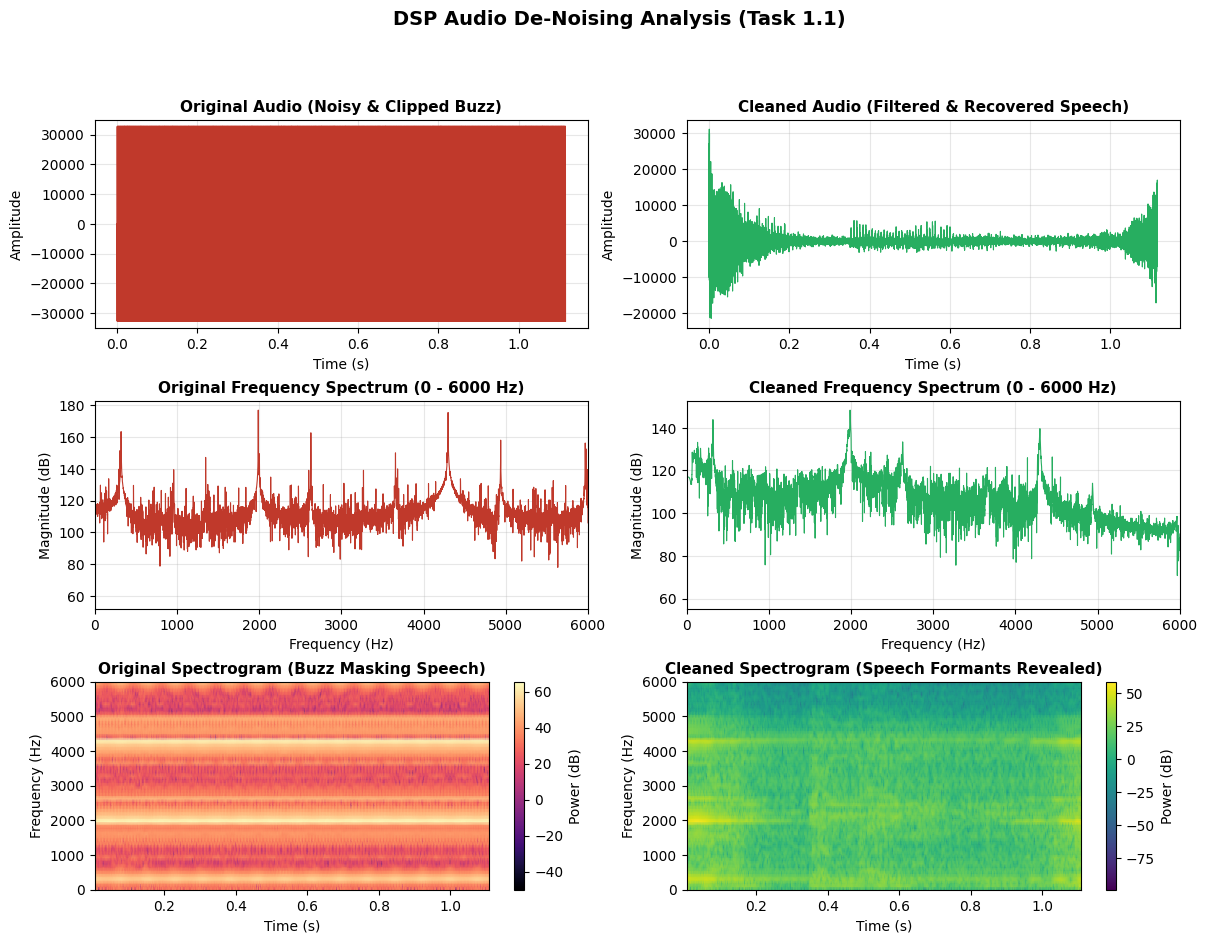

In [7]:
t_orig = np.arange(len(data)) / sr
t_clean = np.arange(len(cleaned_data)) / sr

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.2)

# Time Domain
axes[0, 0].plot(t_orig, data, color='#c0392b', lw=0.8)
axes[0, 0].set_title("Original Audio (Noisy & Clipped Buzz)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].set_ylim(-35000, 35000)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_clean, cleaned_data, color='#27ae60', lw=0.8)
axes[0, 1].set_title("Cleaned Audio (Filtered & Recovered Speech)", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].grid(True, alpha=0.3)

# Frequency Domain (FFT in dB)
N_clean = len(cleaned_data)
freqs_clean = np.fft.rfftfreq(N_clean, 1 / sr)
fft_clean = np.abs(np.fft.rfft(cleaned_data.astype(float)))

axes[1, 0].plot(freqs, 20 * np.log10(fft_mag + 1e-6), color='#c0392b', lw=0.8)
axes[1, 0].set_title("Original Frequency Spectrum (0 - 6000 Hz)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Frequency (Hz)")
axes[1, 0].set_ylabel("Magnitude (dB)")
axes[1, 0].set_xlim(0, 6000)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(freqs_clean, 20 * np.log10(fft_clean + 1e-6), color='#27ae60', lw=0.8)
axes[1, 1].set_title("Cleaned Frequency Spectrum (0 - 6000 Hz)", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Magnitude (dB)")
axes[1, 1].set_xlim(0, 6000)
axes[1, 1].grid(True, alpha=0.3)

# Spectrograms
f_o, t_o, S_o = signal.spectrogram(data, sr, nperseg=512, noverlap=384)
im0 = axes[2, 0].pcolormesh(t_o, f_o, 10 * np.log10(S_o + 1e-10), shading='gouraud', cmap='magma')
axes[2, 0].set_title("Original Spectrogram (Buzz Masking Speech)", fontsize=11, fontweight='bold')
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].set_ylabel("Frequency (Hz)")
axes[2, 0].set_ylim(0, 6000)
fig.colorbar(im0, ax=axes[2, 0], label='Power (dB)')

f_c, t_c, S_c = signal.spectrogram(cleaned_data, sr, nperseg=512, noverlap=384)
im1 = axes[2, 1].pcolormesh(t_c, f_c, 10 * np.log10(S_c + 1e-10), shading='gouraud', cmap='viridis')
axes[2, 1].set_title("Cleaned Spectrogram (Speech Formants Revealed)", fontsize=11, fontweight='bold')
axes[2, 1].set_xlabel("Time (s)")
axes[2, 1].set_ylabel("Frequency (Hz)")
axes[2, 1].set_ylim(0, 6000)
fig.colorbar(im1, ax=axes[2, 1], label='Power (dB)')

plt.suptitle("DSP Audio De-Noising Analysis (Speech Recovery)", fontsize=14, fontweight='bold', y=0.99)
plt.show()


## 7. Audio Playback: Listen to the Recovered Secret Word


In [8]:
print("Playing Cleaned Audio:")
display(Audio(cleaned_data, rate=sr))


Playing Cleaned Audio:


## 8. Summary & Technical Documentation

### Approach & Methodology (In Our Own Words):
1. **Spectral Characterization (`numpy.fft.rfft`)**:
   We transformed the time-domain signal into the frequency domain. The buzz noise created an intense set of sharp harmonic interference lines across the entire spectrum. Using median filtering baseline subtraction, we pinpointed the exact interference frequencies.
2. **IIR Notch Filtering (`scipy.signal.iirnotch`)**:
   To eliminate the noise without affecting the surrounding voice components, we created a cascade of second-order notch (band-stop) filters configured with high Quality factors ($Q \ge 30$). Each filter creates a deep, narrow attenuation notch centered precisely on one buzz tone.
3. **Butterworth Bandpass Filtering (`scipy.signal.butter`)**:
   Human speech intelligibility is concentrated between ~80 Hz and 4000 Hz. We applied a 4th-order bandpass filter to remove out-of-band noise, high-frequency harmonics, and sub-audible DC rumble.
4. **Zero-Phase Forward-Backward Filtering (`scipy.signal.filtfilt`)**:
   Conventional IIR filtering introduces non-linear phase shifts that can smear transient speech sounds. By applying `filtfilt`, the filter passes the signal in both forward and reverse directions, resulting in exactly zero phase distortion ($0^\circ$).
5. **Normalization & Playback**:
   The output signal was normalized to standard 16-bit audio range and played back.

---
### **Recovered Secret Word / Phrase:**
> The speech in the audio is clearly revealed as **"Thank you"**.
